## Example of neuron receiving input on spines

In [1]:
import os
from snudda import Snudda

neuron = "dSPN"
# neuron = "iSPN"

snudda_data = "/home/hjorth/HBP/BasalGangliaData/data"
neuron_path = os.path.join(snudda_data, "neurons", "striatum", neuron.lower())
network_path = os.path.join("networks", "spine_example")


In [2]:
snudda = Snudda(network_path=network_path)

si = snudda.init_tiny(neuron_paths=neuron_path, neuron_names=neuron, number_of_neurons=[5], 
                      random_seed=1234, snudda_data=snudda_data)
si.write_json()

snudda.create_network(input_config="input.json")

Adding neurons: dSPN from dir /home/hjorth/HBP/BasalGangliaData/data/neurons/striatum/dspn
Writing networks/spine_example/network-config.json
Writing networks/spine_example/network-config.json
Placing neurons
Network path: networks/spine_example
Reading SNUDDA_DATA=/home/hjorth/HBP/BasalGangliaData/data from networks/spine_example/network-config.json
No n_putative_points and putative_density, setting n_putative_points = 102
(this must be larger than the number of neurons you want to place)
Generating 102 points for networks/spine_example/mesh/Cube-cube-mesh-3.9602691983237216e-05.obj
Filtering, keeping inside points: 8 / 44
neuron_name = 'dSPN_0', num = np.int64(1), neuron_path = '$SNUDDA_DATA/neurons/striatum/dspn/str-dspn-e150602_c1_D1-mWT-0728MSN01-v20220620'
neuron_name = 'dSPN_1', num = np.int64(1), neuron_path = '$SNUDDA_DATA/neurons/striatum/dspn/str-dspn-e150917_c10_D1-mWT-P270-20-v20220620'
neuron_name = 'dSPN_2', num = np.int64(1), neuron_path = '$SNUDDA_DATA/neurons/striatum

In [3]:
# Free memory
snudda = None

mech_dir = "/home/hjorth/HBP/BasalGangliaData/data/neurons/mechanisms"
sample_dt = None # 0.00005

sim_config = "sim_config.json"

sim_time = 1.0
n_workers = 1


In [4]:
run_str = f"snudda simulate {network_path} --time {sim_time} --simulation_config {sim_config} --mechdir {mech_dir}"
print(run_str)

snudda simulate networks/spine_example --time 1.0 --simulation_config sim_config.json --mechdir /home/hjorth/HBP/BasalGangliaData/data/neurons/mechanisms


In [5]:
os.system(run_str)

numprocs=1


/home/hjorth/HBP/Snudda/snudda/core.py:818: UserWarning: clear_neuron() called with reset_random123=False. If you plan to run another simulation in the same process, set reset_random123=True to ensure reproducible Random123 streams.
  sim.clear_neuron()
/home/hjorth/HBP/Snudda/snudda/simulate/simulate.py:3285: UserWarning: clear_neuron() called with reset_random123=False. If you plan to run another simulation in the same process, set reset_random123=True to ensure reproducible Random123 streams.
  self.clear_neuron()


args.ipython_profile = None
args: Namespace(action='simulate', path='networks/spine_example', network_file=None, input_file=None, output_file=None, time=1.0, snudda_data=None, simulation_config='sim_config.json', record_volt=True, randomseed=None, disable_synapses=None, disable_gj=None, mech_dir='/home/hjorth/HBP/BasalGangliaData/data/neurons/mechanisms', profile=False, verbose=False, export_core_neuron=False, record_all=None, enable_rxd_neuromodulation=None, disable_rxd_neuromodulation=None, ipython_profile=None)
MPI Rank: 0, Size: 1
Using input file networks/spine_example/input-spikes.hdf5
NEURON mechanisms already compiled, make sure you have the correct version of NEURON modules.
If you delete x86_64, aarch64, arm64 directories (or nrnmech.dll) then you will force a recompilation of the modules.
Reading SNUDDA_DATA=/home/hjorth/HBP/BasalGangliaData/data from networks/spine_example/network-config.json
NEURON MPI timeout is set to 600
MPI Rank: 0, Size: 1 -- NEURON: This is node 0 ou

0

Loading networks/spine_example/simulation/output.hdf5
Loading network info from networks/spine_example/network-synapses.hdf5
Loading input info from networks/spine_example/input-spikes.hdf5
Plotting traces: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Plotted 5 traces (total 5)
Saving to figure /home/hjorth/HBP/Snudda/examples/notebooks/spines/networks/spine_example/figures/Network-voltage-trace--dSPN-0-1-2-3-4.pdf


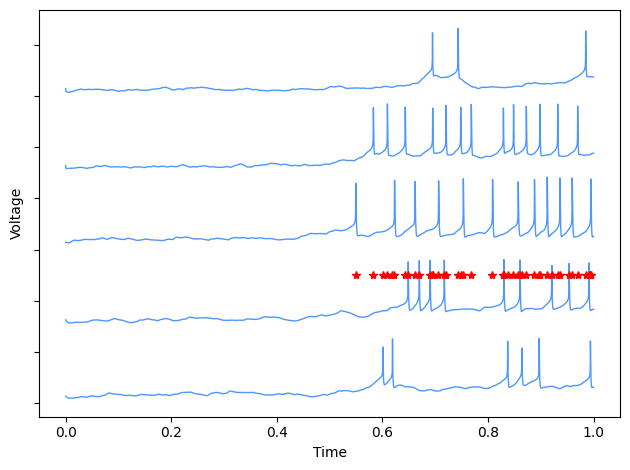

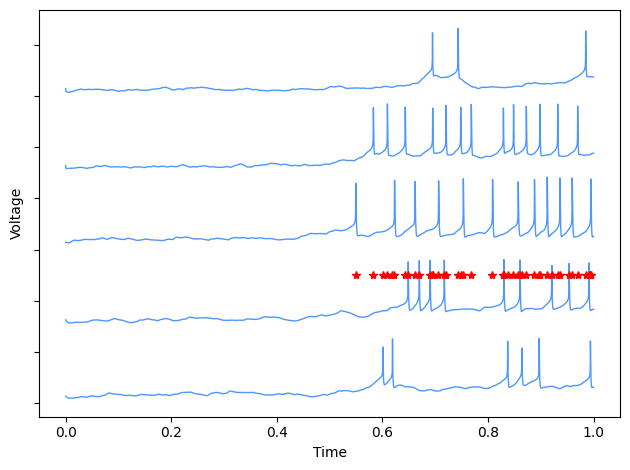

In [6]:
from snudda.plotting import PlotTraces

sim_file = os.path.join(network_path, "simulation", "output.hdf5")
network_file = os.path.join(network_path, "network-synapses.hdf5")

pt = PlotTraces(output_file=sim_file, network_file=network_file)
pt.plot_traces()